# Análisis de Ventas — Tienda de Ropa Online
**Contexto del analisis:** El siguiente es un analisis de la tienda de ropa "Vesper": https://vesper.tiendanegocio.com/

**Objetivo:** identificar qué productos, categorías, talles y regiones impulsan las ventas del negocio, y detectar patrones de estacionalidad para apoyar decisiones de stock y marketing.

**Fuente de datos:** exportación de ventas de la plataforma de e-commerce "Tiendanegocio" (marzo 2025 – septiembre 2026). Los datos personales de compradores (nombre, email, teléfono, dirección) fueron removidos por privacidad en la limpieza de los datos antes de este análisis.

**Preguntas de negocio:**
1. ¿Cómo evolucionaron los ingresos mes a mes? ¿Hay estacionalidad?
2. ¿Qué categorías y diseños puntuales generan más ingresos y unidades vendidas?
3. ¿De qué provincias/ciudades son los clientes?
4. ¿Qué talles rotan más?
5. ¿Las preventas tienen un rol relevante en las ventas?
6. ¿Cuál es el ticket promedio y cómo se compone?


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('ventas_limpio_confirmadas (2).csv', parse_dates=['Fecha'])
df.head()

Total_linea (bruto): $4,774,368


## 1. Overview del dataset

In [22]:
print(f"Filas (líneas de producto): {df.shape[0]}")
print(f"Ventas únicas: {df['# de venta'].nunique()}")
print(f"Rango de fechas: {df['Fecha'].min().date()} a {df['Fecha'].max().date()}")

Filas (líneas de producto): 285
Ventas únicas: 201
Rango de fechas: 2025-03-12 a 2026-09-10


Trabaje con las ventas en estado "Pago Confirmado", que representan el ingreso real y confirmado del negocio. Las "Archivado" y "Pago Pendiente" se excluyen del análisis de ingresos porque no representan ventas efectivas.

**Nota:** septiembre 2026 está incompleto en los datos (solo hasta el día 10), así que no se debe comparar directamente contra meses completos.

## 2. Evolución mensual de ingresos

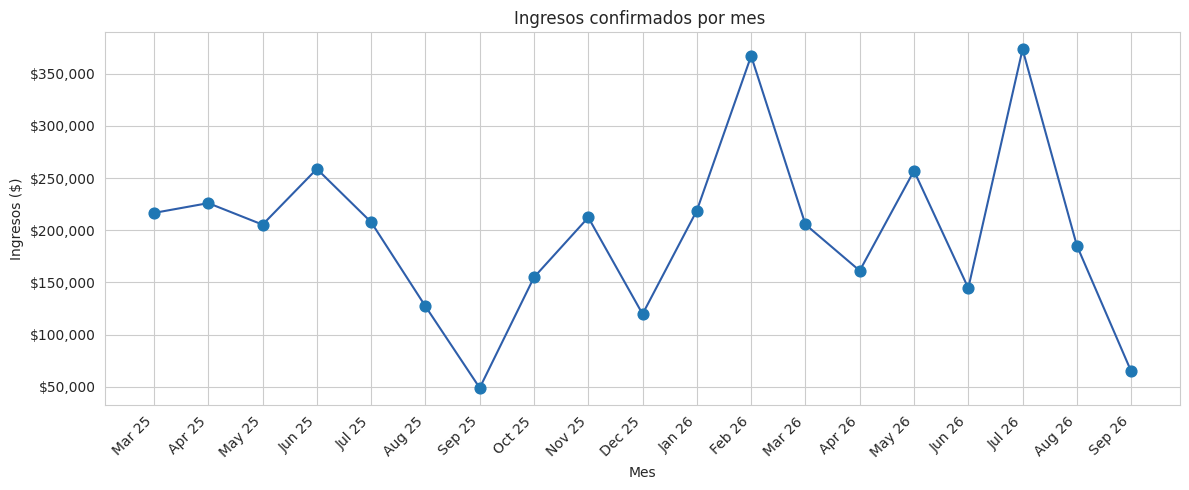

In [41]:
ingresos_mes = df.groupby('Mes')['Total_linea'].sum().sort_index()
labels = pd.to_datetime(ingresos_mes.index).strftime('%b %y')
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(labels, ingresos_mes.values, color='#2E5EAA', linewidth=1.5, zorder=1)
ax.scatter(labels, ingresos_mes.values, s=60, zorder=2)
ax.set_title('Ingresos confirmados por mes ')
ax.set_xlabel('Mes')
ax.set_ylabel('Ingresos ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Se pueden observar picos destacados de ingresos en julio y febrero de 2026. No hay datos de las ventas de febrero 2025 ya que el emprendimiento comenzó en marzo, por lo que no podemos compararlo con febrero 2026.
También se aprecia un mínimo histórico en septiembre 2025. Si bien septiembre 2026 vuelve a mostrar un punto bajo, al ser el mes en curso no se puede afirmar aún que sea un patrón consolidado.


## 3. Categorías y diseños que más venden

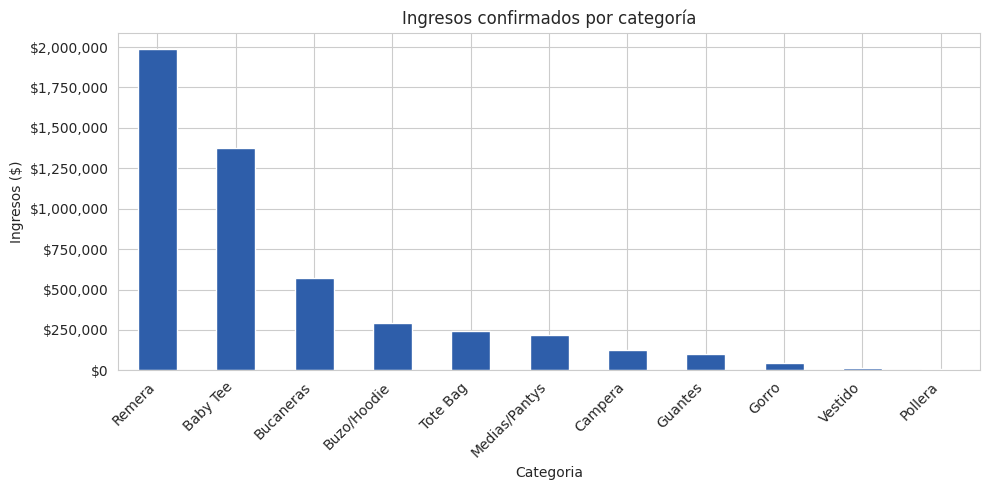

In [24]:
ingresos_cat = df.groupby('Categoria')['Total_linea'].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
ingresos_cat.plot(kind='bar', ax=ax, color='#2E5EAA')
ax.set_title('Ingresos confirmados por categoría')
ax.set_ylabel('Ingresos ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


La categoria de producto mas vendida son las remeras, algo a tener en cuenta a la hora de comprar stock

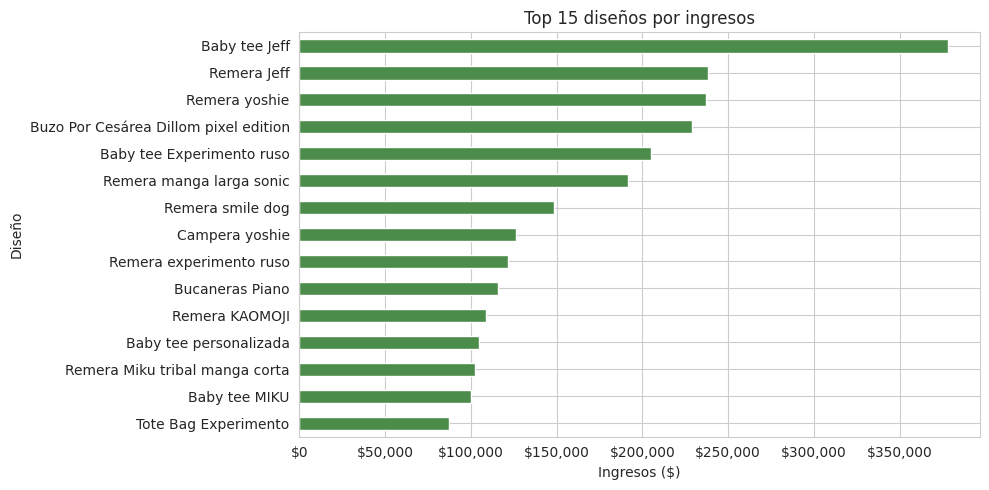

In [25]:
top_disenos = df.groupby('Diseño')['Total_linea'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots()
top_disenos.sort_values().plot(kind='barh', ax=ax, color='#4C8C4A')
ax.set_title('Top 15 diseños por ingresos')
ax.set_xlabel('Ingresos ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()



Las categorías Remera y Baby Tee concentran la mayor parte de los ingresos. A nivel de diseño puntual, el diseño "Jeff" aparece dos veces en el top (como Baby Tee y como Remera), lo que sugiere que es el diseño más popular del catálogo más allá del tipo de prenda. Esto es información que el nombre de producto por sí solo no mostraba con claridad, se identificó agrupando por SKU.

## 4. Distribución geográfica

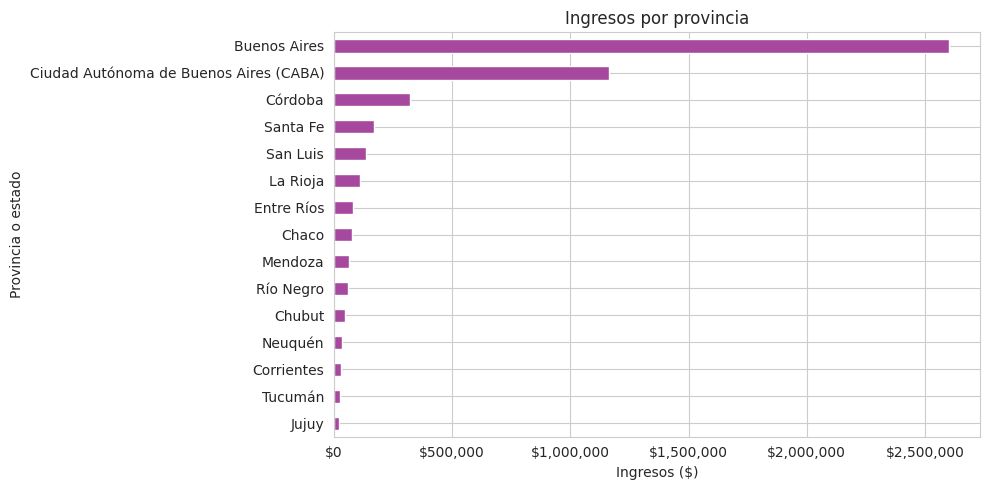

In [26]:
ingresos_prov = df.groupby('Provincia o estado')['Total_linea'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots()
ingresos_prov.sort_values().plot(kind='barh', ax=ax, color='#A6499E')
ax.set_title('Ingresos por provincia')
ax.set_xlabel('Ingresos ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()



Hay una concentración fuerte en Buenos Aires y CABA. Esto tiene sentido para un negocio que despacha por Correo Argentino desde esa zona, pero también marca una oportunidad: si se quiere crecer, conviene entender por qué el resto del país compra menos.
Lo mas probable es que por un lado, al estar el negocio en Buenos Aires tiene un mayor costo de envio a las demas provincias.
Otra posibilidad, es que se trate de la diferencia de poder adquisitivo, Buenos Aires concentra los salarios promedio más altos del sector privado formal y la mayor densidad de clase media y alta con ingresos disponibles para consumo no esencial.

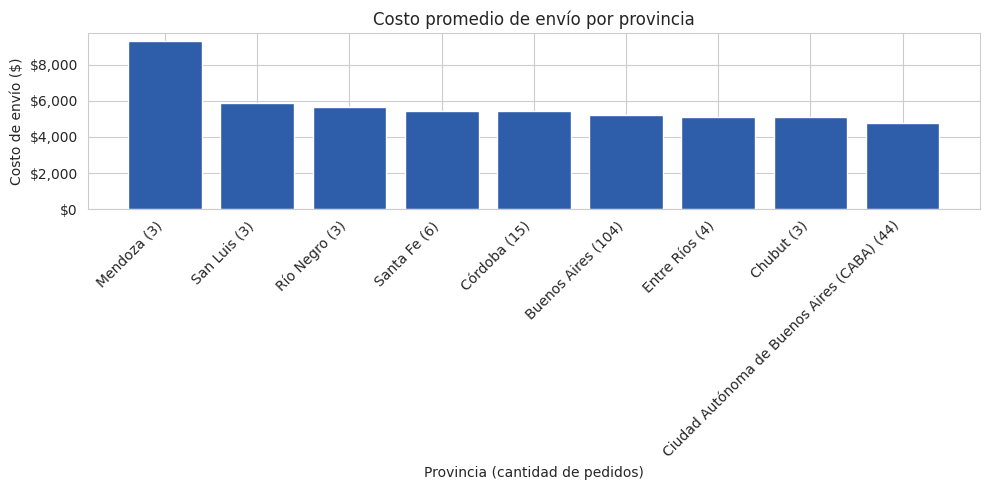

In [27]:
ventas_unicas = df.drop_duplicates('# de venta')

envio_por_provincia = (
    ventas_unicas.groupby('Provincia o estado')['Costo de envío']
    .agg(promedio='mean', pedidos='count')
    .sort_values('promedio', ascending=False)
)

envio_confiable = envio_por_provincia[envio_por_provincia['pedidos'] >= 3]

fig, ax = plt.subplots(figsize=(10, 5))
etiquetas = [f"{prov} ({int(n)})" for prov, n in zip(envio_confiable.index, envio_confiable['pedidos'])]
ax.bar(etiquetas, envio_confiable['promedio'], color='#2E5EAA')
ax.set_title('Costo promedio de envío por provincia')
ax.set_xlabel('Provincia (cantidad de pedidos)')
ax.set_ylabel('Costo de envío ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



In [42]:
ventas_unicas = df.drop_duplicates('# de venta').copy()
ventas_unicas['Zona'] = ventas_unicas['Provincia o estado'].isin(
    ['Buenos Aires', 'Ciudad Autónoma de Buenos Aires (CABA)']
).map({True: 'Buenos Aires/CABA', False: 'Resto del país'})

unidades_por_pedido = df.groupby('# de venta')['Cantidad del producto'].sum()
ventas_unicas['Unidades'] = ventas_unicas['# de venta'].map(unidades_por_pedido)

comparacion_zona = ventas_unicas.groupby('Zona').agg(
    pedidos=('# de venta', 'count'),
    subtotal_promedio=('Subtotal de productos', 'mean'),
    envio_promedio=('Costo de envío', 'mean'),
    total_promedio=('Total', 'mean'),
    unidades_promedio=('Unidades', 'mean'),
).round(0)

comparacion_zona

,pedidos,subtotal_promedio,envio_promedio,total_promedio,unidades_promedio
Zona,,,,,
Buenos Aires/CABA,153,24627.0,5083.0,28440.0,1.0
Resto del país,48,25540.0,5864.0,30228.0,2.0


Aca podemos ver que los pedidos de afuera de Buenos Aires compran en promedio el doble de unidades por pedido, probablemente por el costo y tiempo de envio

## 5. Talles

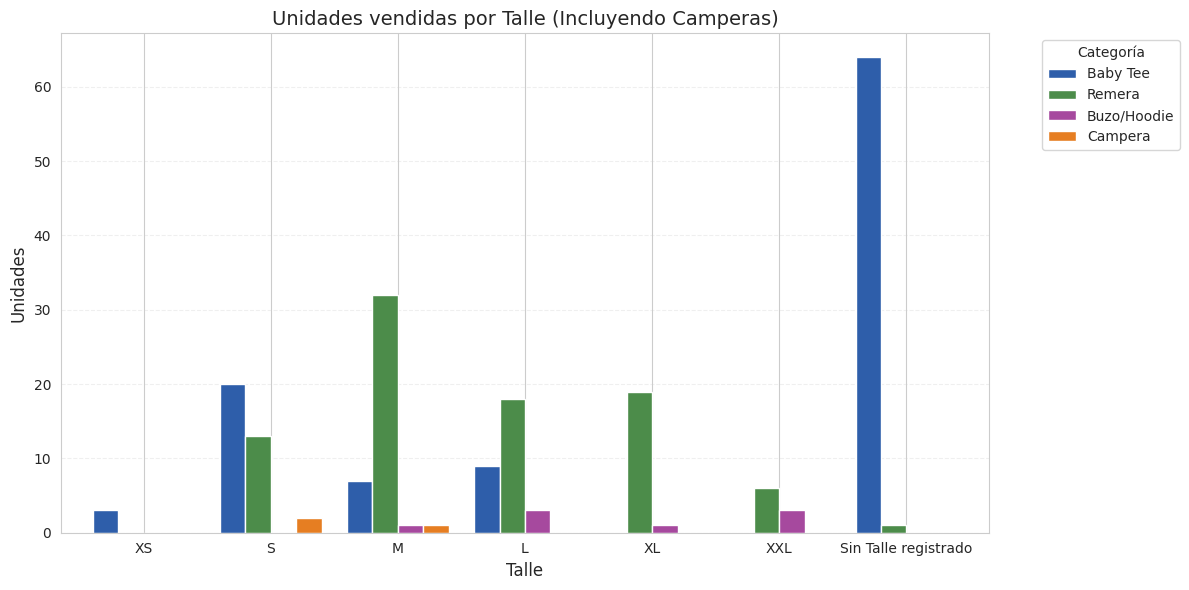

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

dfc_talle_completo = df.copy()

categorias_a_excluir = ['Bucaneras', 'Tote Bag', 'Medias/Pantys']
dfc_talle_completo = dfc_talle_completo[~dfc_talle_completo['Categoria'].isin(categorias_a_excluir)]

dfc_talle_completo['Talle'] = dfc_talle_completo['Talle'].fillna('Sin Talle registrado')

cats_interes = ['Baby Tee', 'Remera', 'Buzo/Hoodie', 'Campera']
disponibles = [c for c in cats_interes if c in dfc_talle_completo['Categoria'].unique()]

unidades_talle_categoria = dfc_talle_completo.groupby(['Talle', 'Categoria'])['Cantidad del producto'].sum().unstack(fill_value=0)

unidades_talle_categoria = unidades_talle_categoria[disponibles]

talles_orden = ['XS', 'S', 'M', 'L', 'XL', 'XXL', 'Sin Talle registrado']
talles_existentes = [t for t in talles_orden if t in unidades_talle_categoria.index]
unidades_talle_categoria = unidades_talle_categoria.reindex(talles_existentes)

fig, ax = plt.subplots(figsize=(12, 6))
colores = ['#2E5EAA', '#4C8C4A', '#A6499E', '#E67E22']
unidades_talle_categoria.plot(kind='bar', ax=ax, width=0.8, color=colores[:len(disponibles)])

ax.set_title('Unidades vendidas por Talle (Incluyendo Camperas)', fontsize=14)
ax.set_xlabel('Talle', fontsize=12)
ax.set_ylabel('Unidades', fontsize=12)
ax.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

El talle no viene en una columna propia en el export, hay que extraerlo del
nombre del producto, y no siempre está presente.

Esto afecta de forma muy despareja a las categorías: Remera tiene talle
identificable en el 99% de sus ventas, pero Baby Tee solo en el 38%.Esto no parece ser una limitación del sistema sino una inconsistencia al cargar los productos Baby Tee puntualmente. El resto de las categorías (Bucaneras, Guantes, Gorros, Tote Bags) no tiene talle identificado en absoluto, pero es esperable: son productos que no usan la escala S-XL ya que son de talle único.
Para evitar esto, a futuro habria que revisar la forma en la que se cargan los datos, y en lo posible usar una base de datos dedicada en vez de extraer los exports de tiendanegocio

# **Insights clave:**
1. Remera y Baby Bee concentran el 67% de los ingresos. El diseño "Jeff" es el mas fuerte del catalogo, vendido en ambos formatos
2. Las ventas suben ~72% en los meses en que la dueña dedica más tiempo a redes sociales. Los meses en los que tiene vacaciones (enero, febrero, julio, agosto) cuando hay más tiempo para publicitar la cuenta en Instagram y TikTok. No es una estacionalidad de mercado (no hay un mes fijo que siempre sea el mejor), sino una estacionalidad ligada directamente al esfuerzo de marketing del negocio. Recomendación: sostener un nivel de actividad en redes más parejo durante el año mediante contenido programado para achicar esa brecha. Cabe aclarar que no saque del dataset la informacion de que esos meses esta de vacaciones, sino que eso es algo que me conto ella.
3. Los pedidos de afuera de Buenos Aires compran en promedio el doble de unidades por pedido, probablemente para amortizar el costo y tiempo de envío. La concentración geográfica en sí parece responder más a alcance de marca que a costo o poder adquisitivo. Recomendación: cruzar este dato con analítica de redes sociales (de dónde vienen los seguidores).
4. Calidad de datos: el talle se cargó de forma pareja en Remera, pero no en Baby Tee. Remera tiene talle identificable en el 99% de sus ventas, Baby Tee, solo en el 38%. Esto no es una limitación técnica sino una inconsistencia puntual al cargar productos Baby Tee. Recomendación: cargar el talle de Baby Tee con el mismo criterio que ya se usa en Remera, para poder gestionar stock por talle con confianza.